In [ ]:
#!pip install matplotlib seaborn gensim
# import plotting libraries
import matplotlib.pyplot as plt

from matplotlib import style

import seaborn as sns
sns.set(style="white", color_codes=True)
sns.set(font_scale=1.5)

from gensim.models import Word2Vec

In [ ]:
# define training data
# sentences = [
#     ['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec'],
# 	['this', 'is', 'the', 'second', 'sentence'],
# 	['yet', 'third', 'sentence'],
# 	['one', 'fourth', 'sentence'],
# 	['and', 'the', 'fifth', 'sentence']]

In [3]:
# define training data
sentences = [
    ['data', 'science', 'Machine', 'AI', 'learning', 'analytics', 'word2vec'],
    ['Machine', 'AI', 'learning','Machine', 'AI', 'learning','Machine', 'AI', 'learning'],
	['soccer', 'rugby', 'playing', 'soccer field', 'big'],
	['yet', 'third', 'sentence'],
	['one', 'fourth', 'sentence'],
	['and', 'the', 'fifth', 'sentence']]

In [4]:
# train model
model = Word2Vec(sentences=sentences, vector_size=2, min_count=1)

In [5]:
# summarize the loaded model
print(model)

Word2Vec<vocab=20, vector_size=2, alpha=0.025>


In [9]:
# Get the list of words in the vocabulary
words_in_vocab = model.wv.index_to_key
words_in_vocab

['learning',
 'AI',
 'Machine',
 'sentence',
 'fifth',
 'the',
 'and',
 'fourth',
 'one',
 'third',
 'yet',
 'big',
 'soccer field',
 'playing',
 'rugby',
 'soccer',
 'word2vec',
 'analytics',
 'science',
 'data']

In [13]:
# Get the frequency of a specific word
word = "learning"
frequency = model.wv.get_vecattr(word, "count")
frequency

np.int64(4)

In [14]:
# Get the vector for a specific word
vector = model.wv.get_vector(word)
vector

array([-0.02681136,  0.01182157], dtype=float32)

In [15]:
model.wv[word]

array([-0.02681136,  0.01182157], dtype=float32)

In [78]:
from scipy.spatial import distance

In [77]:
# Compute the Cosine distance between 1-D arrays
distance.cosine(model.wv['data'], model.wv['science'])

AttributeError: 'KeyedVectors' object has no attribute 'wv'

In [76]:
cosine_sim = 1 - distance.cosine(model.wv['data'], model.wv['science'])
cosine_sim

AttributeError: 'KeyedVectors' object has no attribute 'wv'

A cosine similarity value of -0.8276093006134033 indicates that the two vectors being compared are somewhat dissimilar and have an angle of approximately 135 degrees between them in the vector space. 

In [75]:
import numpy as np

In [74]:
# method - 2 - using numpy
# manually compute cosine similarity
dot = np.dot(model.wv['data'], model.wv['science'])
norma = np.linalg.norm(model.wv['data'])
normb = np.linalg.norm(model.wv['science'])
cos = dot / (norma * normb)

print("Cosine similarity is {}".format(cos))
print("Cosine distance   is {}".format(1-cos))

AttributeError: 'KeyedVectors' object has no attribute 'wv'

In [72]:
# save model
model.save('model.bin')

INFO - 16:03:20: KeyedVectors lifecycle event {'fname_or_handle': 'model.bin', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-11-15T16:03:20.613866', 'gensim': '4.4.0', 'python': '3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26100-SP0', 'event': 'saving'}
INFO - 16:03:20: storing np array 'vectors' to model.bin.vectors.npy
INFO - 16:03:20: saved model.bin


In [73]:
# load model
new_model = Word2Vec.load('model.bin')
print(new_model)

INFO - 16:03:25: loading Word2Vec object from model.bin
INFO - 16:03:25: loading vectors from model.bin.vectors.npy with mmap=None
INFO - 16:03:25: KeyedVectors lifecycle event {'fname': 'model.bin', 'datetime': '2025-11-15T16:03:25.819289', 'gensim': '4.4.0', 'python': '3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26100-SP0', 'event': 'loaded'}


AttributeError: Model of type <class 'gensim.models.keyedvectors.KeyedVectors'> can't be loaded by <class 'gensim.models.word2vec.Word2Vec'>

In [23]:
# Get all word vectors
all_vectors = model.wv.vectors
all_vectors

array([[-0.02681136,  0.01182157],
       [ 0.25516748,  0.45046365],
       [-0.4651475 , -0.35584044],
       [ 0.32294363,  0.4486494 ],
       [-0.2507714 , -0.18816859],
       [ 0.36902523, -0.07667357],
       [-0.22683066,  0.32770258],
       [-0.24300802, -0.09080088],
       [ 0.14382899,  0.04959369],
       [-0.41426075, -0.4724409 ],
       [ 0.3655883 ,  0.2535131 ],
       [ 0.33787403,  0.03809538],
       [ 0.31754452, -0.1702683 ],
       [-0.04732007,  0.28842866],
       [-0.37620696, -0.19694182],
       [-0.37558976, -0.04655001],
       [ 0.47690594, -0.36595833],
       [-0.11668843, -0.09688705],
       [ 0.40387183, -0.2965448 ],
       [ 0.00225812, -0.2376867 ]], dtype=float32)

#### Plot Word Vectors Using PCA

In [24]:
from sklearn.decomposition import PCA
from matplotlib import pyplot
%matplotlib inline

In [25]:
pca    = PCA(n_components=2)
result = pca.fit_transform(all_vectors)

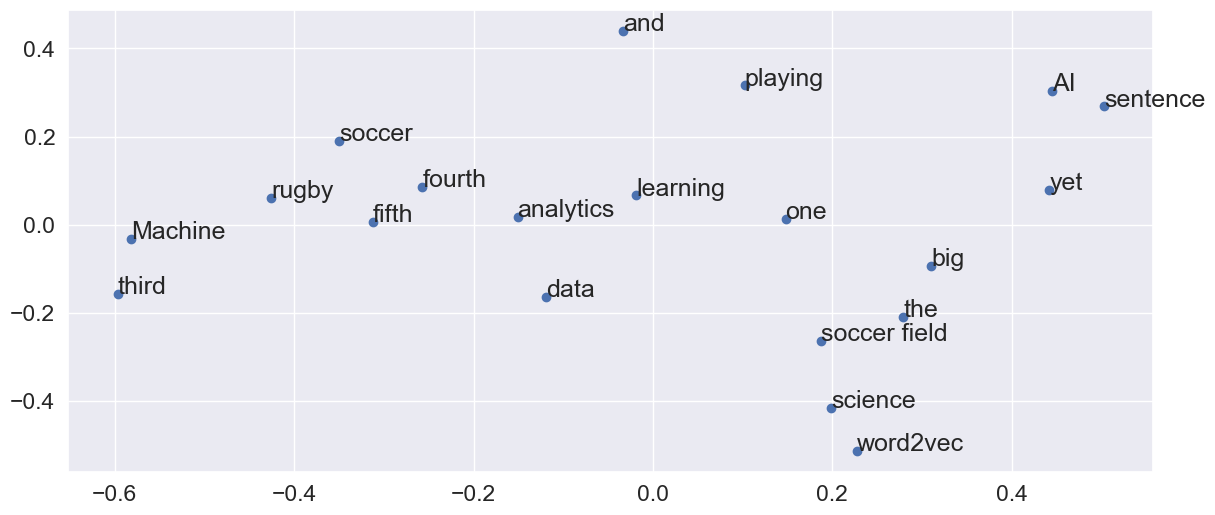

In [26]:
plt.figure(figsize=(14, 6))
plt.scatter(result[:, 0], result[:, 1])

# Get the list of words in the vocabulary
words = model.wv.index_to_key


for i, word in enumerate(words):
	pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))

#### Example 2

#### Load Google’s Word2Vec Embedding
- Training your own word vectors may be the best approach for a given NLP problem.

- But it can take a long time, a fast computer with a lot of RAM and disk space, and perhaps some expertise in finessing the input data and training algorithm.

- An alternative is to simply use an existing `pre-trained word embedding`.

- A pre-trained model is nothing more than a file containing tokens and their associated word vectors. 

- The pre-trained Google `word2vec model` was trained on `Google news data` (about 100 billion words); it contains 3 million words and phrases and was fit using 300-dimensional word vectors.

It is a 1.53 Gigabytes file. You can download it from here: GoogleNews-vectors-negative300.bin.gz https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit



In [27]:
from gensim.models import KeyedVectors

In [30]:
# load the google word2vec model
filename = r'D:\Makesh\Working\AI\RPS\Day04\Dataset\GoogleNews-vectors-negative300.bin'
#model_path = 'path/to/GoogleNews-vectors-negative300.bin'

In [31]:
model    = KeyedVectors.load_word2vec_format(filename, 
                                             binary= True, 
                                             limit = 100000)

In [38]:
model.vector_size

300

In [40]:
# Get the vocabulary size
vocab_size = len(model.key_to_index)

print("Vocabulary size:", vocab_size)

Vocabulary size: 100000


#### Examples

calculate: (king - man) + woman = ?

In [41]:
result = model.most_similar(positive=['woman', 'king'], negative=['man'], topn=10)

result

[('queen', 0.7118193507194519),
 ('monarch', 0.6189674139022827),
 ('princess', 0.5902431011199951),
 ('crown_prince', 0.5499460697174072),
 ('prince', 0.5377321839332581),
 ('kings', 0.5236844420433044),
 ('queens', 0.518113374710083),
 ('sultan', 0.5098593235015869),
 ('monarchy', 0.5087411403656006),
 ('royal_palace', 0.5087166428565979)]

In [42]:
result = model.most_similar(positive=['India', 'Riyadh'], negative=['Bangalore'], topn=4)

result

[('Saudi_Arabia', 0.7524831891059875),
 ('Saudi', 0.7031731009483337),
 ('Saudis', 0.6339676380157471),
 ('Saudi_Arabian', 0.6122680306434631)]

what if the token is not in the model

In [43]:
result = model.most_similar(positive=['India', 'London'], negative=['Delhi'], topn=4)

result

[('UK', 0.6248663067817688),
 ('Britain', 0.607151985168457),
 ('Europe', 0.5445290207862854),
 ('Asia', 0.5214443206787109)]

In [60]:
result = model.most_similar(positive=['India', 'Karachi'], negative=['Bangalore'], topn=4)

result

[('Pakistan', 0.7550593614578247),
 ('Bangladesh', 0.6441815495491028),
 ('Balochistan', 0.6238784790039062),
 ('Lahore', 0.6214929819107056)]

In [64]:
result = model.most_similar(positive=['Tamilnadu', 'Chennai'], negative=['Kerala'], topn=4)

result

[('Madurai', 0.6849717497825623),
 ('Tamil_Nadu', 0.679295003414154),
 ('Hyderabad', 0.6749228835105896),
 ('Visakhapatnam', 0.6634507775306702)]

#### Example 3

In [45]:
import re  # For preprocessing
import pandas as pd  # For data handling

pd.set_option('display.max_colwidth', 120)

from time import time  # To time our operations
from collections import defaultdict  # For word frequency

import spacy  # For preprocessing

import logging  # Setting up the loggings to monitor gensim
logging.basicConfig(format="%(levelname)s - %(asctime)s: %(message)s", datefmt= '%H:%M:%S', level=logging.INFO)

This dataset contains the characters, locations, episode details, and script lines for approximately 600 Simpsons episodes, dating back to 1989. It can be found here: https://www.kaggle.com/ambarish/fun-in-text-mining-with-simpsons/data (~25MB)

In [65]:
df = pd.read_csv(r'D:\Makesh\Working\AI\RPS\Day04\Dataset\Simphsons\simpsons_script_lines.csv')
df.shape

C:\Users\reach\AppData\Local\Temp\ipykernel_18068\3723043328.py:1: DtypeWarning: Columns (4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'D:\Makesh\Working\AI\RPS\Day04\Dataset\Simphsons\simpsons_script_lines.csv')


(158271, 13)

In [66]:
df.sample(5)

,id,episode_id,number,raw_text,timestamp_in_ms,speaking_line,character_id,location_id,raw_character_text,raw_location_text,spoken_words,normalized_text,word_count
111195,121365,428,238,Homer Simpson: And she's ready for a night of anonymous sex with multiple partners. (CHUCKLES),1028000,True,2.0,15.0,Homer Simpson,Moe's Tavern,And she's ready for a night of anonymous sex with multiple partners.,and shes ready for a night of anonymous sex with multiple partners,12
41125,50972,181,109,"Marge Simpson: Homer, I want you to look at this drawing Bart did.",543000,True,1.0,5.0,Marge Simpson,Simpson Home,"Homer, I want you to look at this drawing Bart did.",homer i want you to look at this drawing bart did,11
96549,106620,372,72,"""Mike Wallace"": Tonight on ""48 Minutes"", we look at America's number-one problem: criminals who prey on the elderly ...",431000,True,4615.0,5.0,Mike Wallace,Simpson Home,"Tonight on ""48 Minutes"", we look at America's number-one problem: criminals who prey on the elderly people who watch...",tonight on 48 minutes we look at americas number-one problem criminals who prey on the elderly people who watch this...,21
136727,147142,526,25,Lisa Simpson: I'm gonna put all my stuffed animals on it!,98000,true,9,5.0,Lisa Simpson,Simpson Home,I'm gonna put all my stuffed animals on it!,im gonna put all my stuffed animals on it,9
141646,152085,544,169,Female Dj: It's on tonight. And everyone who ever took anyone's lunch money is there.,813000,true,6520,4082.0,Female Dj,Subway Station,It's on tonight. And everyone who ever took anyone's lunch money is there.,its on tonight and everyone who ever took anyones lunch money is there,13


In [67]:
df.isnull().sum()

id                        0
episode_id                0
number                    0
raw_text                  0
timestamp_in_ms           0
speaking_line             0
character_id          17521
location_id             407
raw_character_text    17522
raw_location_text       408
spoken_words          26159
normalized_text       26184
word_count            26159
dtype: int64

In [68]:
# Removing the missing values:
df = df.dropna().reset_index(drop=True)
df.isnull().sum()

id                    0
episode_id            0
number                0
raw_text              0
timestamp_in_ms       0
speaking_line         0
character_id          0
location_id           0
raw_character_text    0
raw_location_text     0
spoken_words          0
normalized_text       0
word_count            0
dtype: int64

#### Cleaning:

We are lemmatizing and removing the stopwords and non-alphabetic characters for each line of dialogue.

In [50]:
nlp = spacy.load('en_core_web_sm', disable=['ner', 'parser']) # disabling Named Entity Recognition for speed

In [69]:
def cleaning(doc):
    # Lemmatizes and removes stopwords
    # doc needs to be a spacy Doc object
    txt = [token.lemma_ for token in doc if not token.is_stop]
    
    # Word2Vec uses context words to learn the vector representation of a target word,
    # if a sentence is only one or two words long, the benefit for the training is very small
    
    if len(txt) > 2:
        return ' '.join(txt)

In [70]:
#%%time

# Removes non-alphabetic characters:
brief_cleaning = (re.sub("[^A-Za-z']+", ' ', str(row)).lower() for row in df['spoken_words'])

#### Taking advantage of spaCy .pipe() 

In [71]:
%%time
## takes about 3 mins
t = time()

txt = [cleaning(doc) for doc in nlp.pipe(brief_cleaning, batch_size=5000)]

print('Time to clean up everything: {} mins'.format(round((time() - t) / 60, 2)))

Time to clean up everything: 3.59 mins
CPU times: total: 3min 10s
Wall time: 3min 35s


In [ ]:
# Put the results in a DataFrame to remove missing values and duplicates:
df_clean = pd.DataFrame({'clean': txt})
df_clean = df_clean.dropna().drop_duplicates()

df_clean.shape

In [ ]:
df_clean.sample(10)

#### Bigrams:
We are using Gensim __Phrases__ package to automatically detect common phrases (bigrams) from a list of sentences.

In [ ]:
from gensim.models.phrases import Phrases, Phraser

As Phrases() takes a list of list of words as input:

In [ ]:
sent = [row.split() for row in df_clean['clean']]

In [ ]:
phrases = Phrases(sent, min_count=30, progress_per=10000)

Transform the corpus based on the bigrams detected:

In [ ]:
sentences = phrases[sent]

#### Most Frequent Words:
Mainly a sanity check of the effectiveness of the lemmatization, removal of stopwords, and addition of bigrams.

In [ ]:
word_freq = defaultdict(int)

for sent in sentences:
    for i in sent:
        word_freq[i] += 1
        
len(word_freq)

In [ ]:
sorted(word_freq, key=word_freq.get, reverse=True)[:10]

#### Training the model
Gensim Word2Vec Implementation:

In [ ]:
import multiprocessing

from gensim.models import Word2Vec

separate the training in 3 distinctive steps for clarity and monitoring.

1. Word2Vec():
In this first step, set up the parameters of the model one-by-one.
do not supply the parameter sentences, and therefore leave the model uninitialized, purposefully.

2. build_vocab():
Here it builds the vocabulary from a sequence of sentences and thus initialized the model.
With the loggings, we can follow the progress and even more important, the effect of __min_count__ and __sample__ on the word corpus. 

3. train():
Finally, trains the model.
The loggings here are mainly useful for monitoring, making sure that no threads are executed instantaneously.

In [ ]:
cores = multiprocessing.cpu_count() # Count the number of cores in a computer
cores

#### The parameters:
- min_count = int - 

Ignores all words with total absolute frequency lower than this - (2, 100)

- window = int - 

The maximum distance between the current and predicted word within a sentence. E.g. window words on the left and window words on the left of our target - (2, 10)

- size = int - 

Dimensionality of the feature vectors. - (50, 300)

- sample = float - 

The threshold for configuring which higher-frequency words are randomly downsampled. Highly influencial. - (0, 1e-5)

- alpha = float - 

The initial learning rate - (0.01, 0.05)

- min_alpha = float - 

Learning rate will linearly drop to min_alpha as training progresses. To set it: alpha - (min_alpha * epochs) ~ 0.00

-

In [ ]:
%%time
w2v_model = Word2Vec(min_count=20,
                     window=2,
                     vector_size=300,
                     sample=6e-5, 
                     alpha=0.03, 
                     min_alpha=0.0007, 
                     negative=20,
                     workers=cores-1)

### Building the Vocabulary Table:
Word2Vec requires us to build the vocabulary table (simply digesting all the words and filtering out the unique words, and doing some basic counts on them):

In [ ]:
t = time()

w2v_model.build_vocab(sentences, progress_per=10000)

print('Time to build vocab: {} mins'.format(round((time() - t) / 60, 2)))

### Training of the model:
Parameters of the training:

total_examples = int - Count of sentences;

epochs = int - Number of iterations (epochs) over the corpus - [10, 20, 30]

In [ ]:
%%time
t = time()

w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=30, report_delay=1)

print('Time to train the model: {} mins'.format(round((time() - t) / 60, 2)))

In [ ]:
# calling init_sims(), which will make the model much more memory-efficient:

w2v_model.init_sims(replace=True)

#### Exploring the model
Most similar to:
Here, we will ask our model to find the word most similar to some of the most iconic characters of the Simpsons!

In [ ]:
w2v_model.wv.most_similar(positive=["jack"])

In [ ]:
w2v_model.wv.most_similar(positive=["homer_simpson"])

## Similarities:
Here, we will see how similar are two words to each other :

In [ ]:
w2v_model.wv.similarity("homer", 'tavern')

In [ ]:
w2v_model.wv.similarity('maggie', 'baby')

## Odd-One-Out:
Here, we ask our model to give us the word that does not belong to the list!

Between Jimbo, Milhouse, and Kearney, who is the one who is not a bully?

In [ ]:
w2v_model.wv.doesnt_match(['jimbo', 'milhouse', 'kearney'])

In [ ]:
w2v_model.wv.doesnt_match(["nelson", "bart", "milhouse"])

In [ ]:
# how is the relationship between Homer and his two sister-in-laws?

w2v_model.wv.doesnt_match(['homer', 'patty', 'selma'])

In [ ]:
w2v_model.wv.most_similar(positive=["bart"])

## Analogy difference:

Which word is to woman as homer is to marge?

In [ ]:
w2v_model.wv.most_similar(positive=["woman", "homer"], negative=["marge"], topn=3)

"man" comes at the first position, that looks about right!

Which word is to woman as bart is to man?

In [ ]:
w2v_model.wv.most_similar(positive=["woman", "bart"], negative=["man"], topn=3)